In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
import hdbscan
import warnings
from astroquery.gaia import Gaia
warnings.filterwarnings('ignore')

# 1. QUERY DATA

In [11]:
query = f"""
SELECT
    ra, dec, parallax, parallax_over_error,
    pmra, pmdec, phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 50 AND 75
AND dec BETWEEN 15 AND 35
AND parallax BETWEEN 4 AND 12
AND parallax_over_error > 5
AND pmra IS NOT NULL
AND pmdec IS NOT NULL
"""
# parallax BETWEEN 4 AND 12 = jarak 83-250 pc
# ini bracket yang cover Pleiades (~7.4 mas) dan Taurus (~7.1 mas)
# sekaligus membuang foreground/background stars yang tidak relevan

job = Gaia.launch_job_async(query)
df = job.get_results().to_pandas()
print(f"Data shape: {df.shape}")

INFO: Query finished. [astroquery.utils.tap.core]
Data shape: (48039, 7)


# 2. EDA


--- Basic Stats ---
                 ra           dec      parallax  parallax_over_error  \
count  48039.000000  48039.000000  48039.000000         48039.000000   
mean      62.654057     24.889395      5.790279           101.065033   
std        7.169402      5.663007      1.686482           120.139526   
min       50.000508     15.000781      4.000012             5.001040   
25%       56.557579     20.104996      4.481917            17.627070   
50%       62.494104     24.702239      5.234850            49.488831   
75%       68.908198     29.716776      6.683135           141.584785   
max       74.999189     34.999477     11.997667           875.556091   

               pmra         pmdec  phot_g_mean_mag  
count  48039.000000  48039.000000     47995.000000  
mean      13.969253    -25.050865        16.554916  
std       32.121447     30.828395         2.848780  
min     -159.597971   -830.738754         2.197542  
25%       -3.424474    -38.511269        15.003357  
50%        9

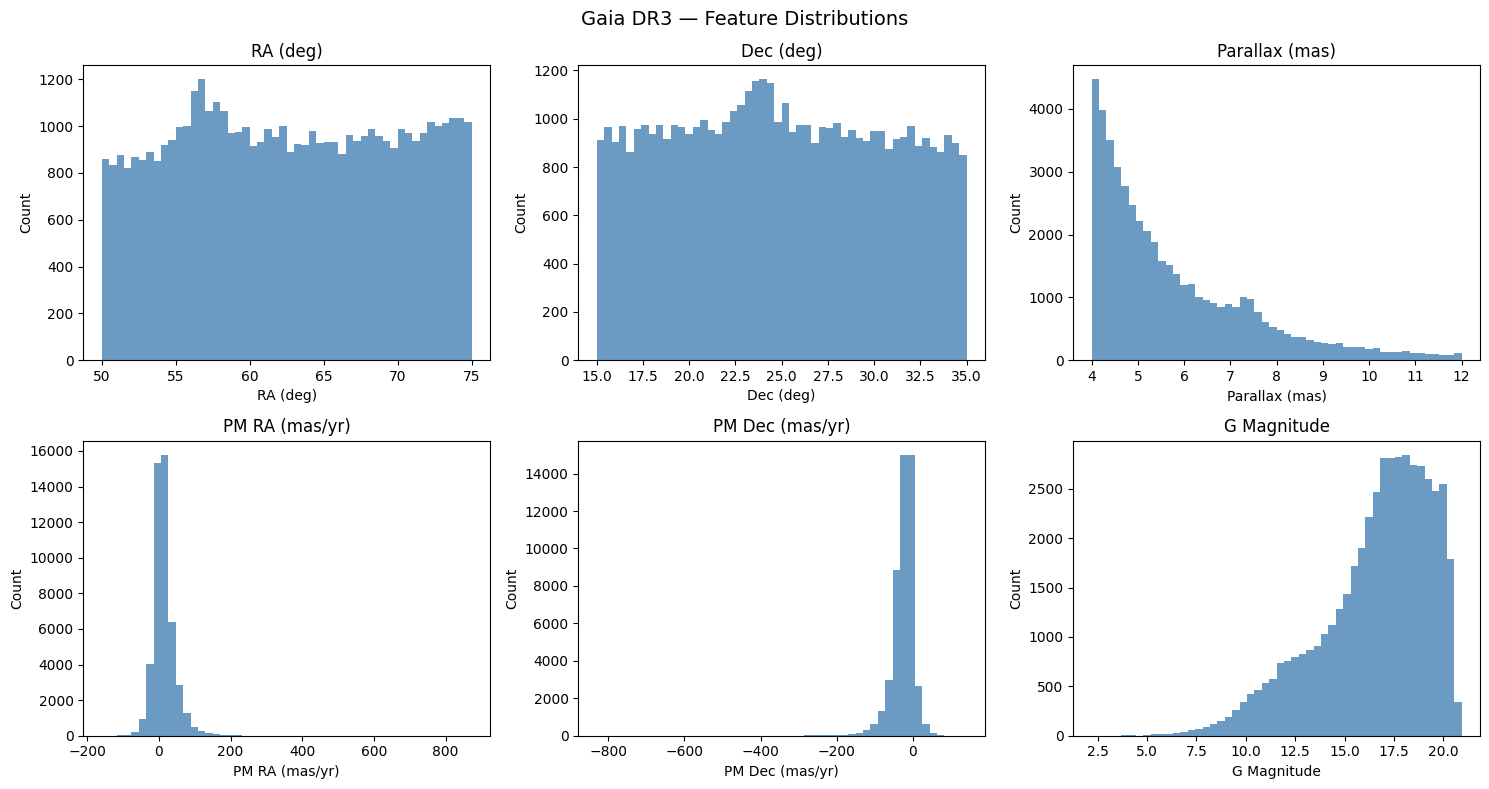

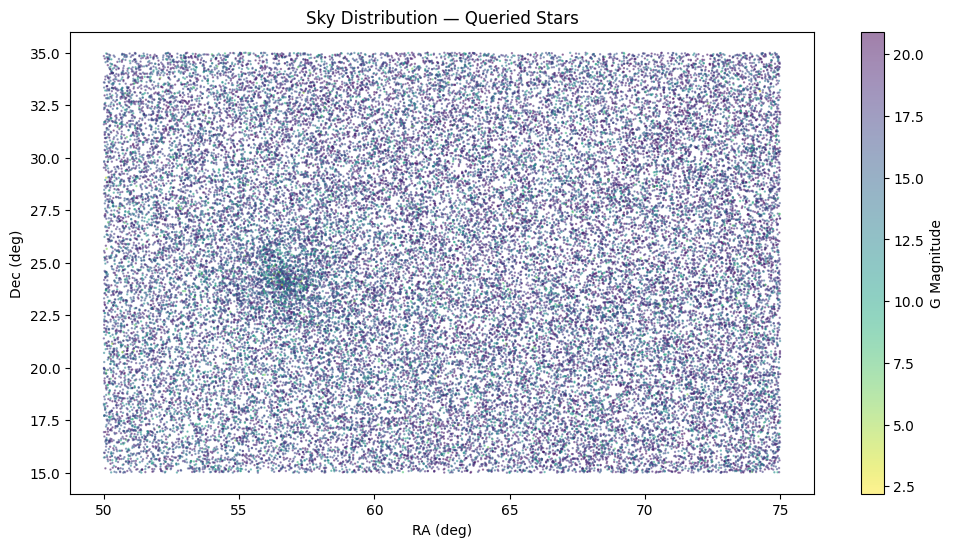

In [12]:
print("\n--- Basic Stats ---")
print(df.describe())

print("\n--- Missing Values ---")
print(df.isnull().sum())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Gaia DR3 — Feature Distributions", fontsize=14)

cols = ['ra', 'dec', 'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag']
labels = ['RA (deg)', 'Dec (deg)', 'Parallax (mas)', 'PM RA (mas/yr)', 'PM Dec (mas/yr)', 'G Magnitude']

for ax, col, label in zip(axes.flatten(), cols, labels):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(label)

plt.tight_layout()
plt.savefig('media/eda_distributions.png', dpi=150)
plt.show()

# Sky plot (RA vs Dec)
plt.figure(figsize=(12, 6))
plt.scatter(df['ra'], df['dec'], s=0.5, alpha=0.5, c=df['phot_g_mean_mag'], cmap='viridis_r')
plt.colorbar(label='G Magnitude')
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('Sky Distribution — Queried Stars')
plt.savefig('media/eda_sky.png', dpi=150)
plt.show()


# 3. PREPROCESSING

In [13]:
# Drop NaN
df_clean = df.dropna().copy()
print(f"\nAfter dropna: {df_clean.shape}")

# Remove extreme outlier parallax (> 3 sigma)
mu, sigma = df_clean['parallax'].mean(), df_clean['parallax'].std()
df_clean = df_clean[np.abs(df_clean['parallax'] - mu) < 3 * sigma]
print(f"After outlier filter: {df_clean.shape}")


After dropna: (47995, 7)
After outlier filter: (47242, 7)


# 4. KOORDINAT TRANSFORM -> Cartesian (parsec)


In [14]:
dist     = 1000.0 / df_clean['parallax']   # mas → parsec (1/parallax dalam arcsec = 1000/parallax_mas)
ra_rad   = np.radians(df_clean['ra'])
dec_rad  = np.radians(df_clean['dec'])

df_clean['x'] = dist * np.cos(dec_rad) * np.cos(ra_rad)
df_clean['y'] = dist * np.cos(dec_rad) * np.sin(ra_rad)
df_clean['z'] = dist * np.sin(dec_rad)

print("\n--- 3D Coordinate Stats (parsec) ---")
print(df_clean[['x', 'y', 'z']].describe())


--- 3D Coordinate Stats (parsec) ---
                  x             y             z
count  47242.000000  47242.000000  47242.000000
mean      76.630953    148.380278     78.234585
std       25.851845     35.916824     25.069429
min       20.234625     59.933616     24.212390
25%       57.015132    119.759626     58.720297
50%       73.139108    151.496476     75.370513
75%       94.729374    176.657663     96.330550
max      153.282996    231.450539    142.940390


# 5. FEATURE CONSTRUCTION & SCALING

In [15]:
# x, y, z = posisi 3D
# pmra, pmdec = proper motion (bintang satu gugus bergerak bersama)
features = ['x', 'y', 'z', 'pmra', 'pmdec']
X = df_clean[features].values

scaler   = RobustScaler()
X_scaled = scaler.fit_transform(X)

# 6. HDBSCAN - tuned untuk Pleiades + Taurus

In [16]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=80,         # minimum anggota gugus
    min_samples=15,              # core point threshold
    cluster_selection_epsilon=0.3,
    metric='euclidean',
    cluster_selection_method='eom'
)

labels           = clusterer.fit_predict(X_scaled)
df_clean['cluster'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise    = np.sum(labels == -1)
noise_pct  = n_noise / len(labels) * 100

print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise} ({noise_pct:.1f}%)")
print("\nCluster sizes:")
print(pd.Series(labels[labels != -1]).value_counts().head(10))

Clusters found : 2
Noise points   : 42354 (89.7%)

Cluster sizes:
1    2875
0    2013
Name: count, dtype: int64


# 7. EVALUASI

In [17]:
mask = labels != -1
if mask.sum() > 1 and n_clusters > 1:
    sil = silhouette_score(X_scaled[mask], labels[mask],
                           sample_size=min(10000, mask.sum()))
    print(f"\nSilhouette Score : {sil:.4f}")

# Cluster summary table
cluster_df = df_clean[df_clean['cluster'] != -1]
summary = cluster_df.groupby('cluster').agg(
    n_stars      = ('cluster', 'count'),
    mean_ra      = ('ra', 'mean'),
    mean_dec     = ('dec', 'mean'),
    mean_plx     = ('parallax', 'mean'),
    mean_dist_pc = ('parallax', lambda p: round(1000 / p.mean(), 1)),
    mean_pmra    = ('pmra', 'mean'),
    mean_pmdec   = ('pmdec', 'mean'),
    mean_mag     = ('phot_g_mean_mag', 'mean')
).sort_values('n_stars', ascending=False)

print("\n--- Cluster Summary ---")
print(summary.to_string())

# Identifikasi Pleiades dan Taurus secara otomatis
# Pleiades: RA ~56.6, Dec ~24.1, parallax ~7.4 mas
# Taurus  : RA ~65.0, Dec ~28.0, parallax ~7.1 mas
for cid, row in summary.iterrows():
    d_pleiades = np.sqrt((row['mean_ra'] - 56.6)**2 + (row['mean_dec'] - 24.1)**2)
    d_taurus   = np.sqrt((row['mean_ra'] - 65.0)**2 + (row['mean_dec'] - 28.0)**2)
    if d_pleiades < 3:
        print(f"\nCluster {cid} kemungkinan PLEIADES (n={row['n_stars']}, dist={row['mean_dist_pc']} pc)")
    if d_taurus < 5:
        print(f"\nCluster {cid} kemungkinan TAURUS (n={row['n_stars']}, dist={row['mean_dist_pc']} pc)")



Silhouette Score : 0.4166

--- Cluster Summary ---
         n_stars    mean_ra   mean_dec  mean_plx  mean_dist_pc  mean_pmra  mean_pmdec   mean_mag
cluster                                                                                         
1           2875  66.944383  25.313195  5.378361         185.9   3.254001  -10.438881  16.874649
0           2013  57.722198  24.715069  7.085017         141.1  19.372057  -42.703448  15.491435

Cluster 1 kemungkinan TAURUS (n=2875.0, dist=185.9 pc)

Cluster 0 kemungkinan PLEIADES (n=2013.0, dist=141.1 pc)


# 8. VISUALISASI

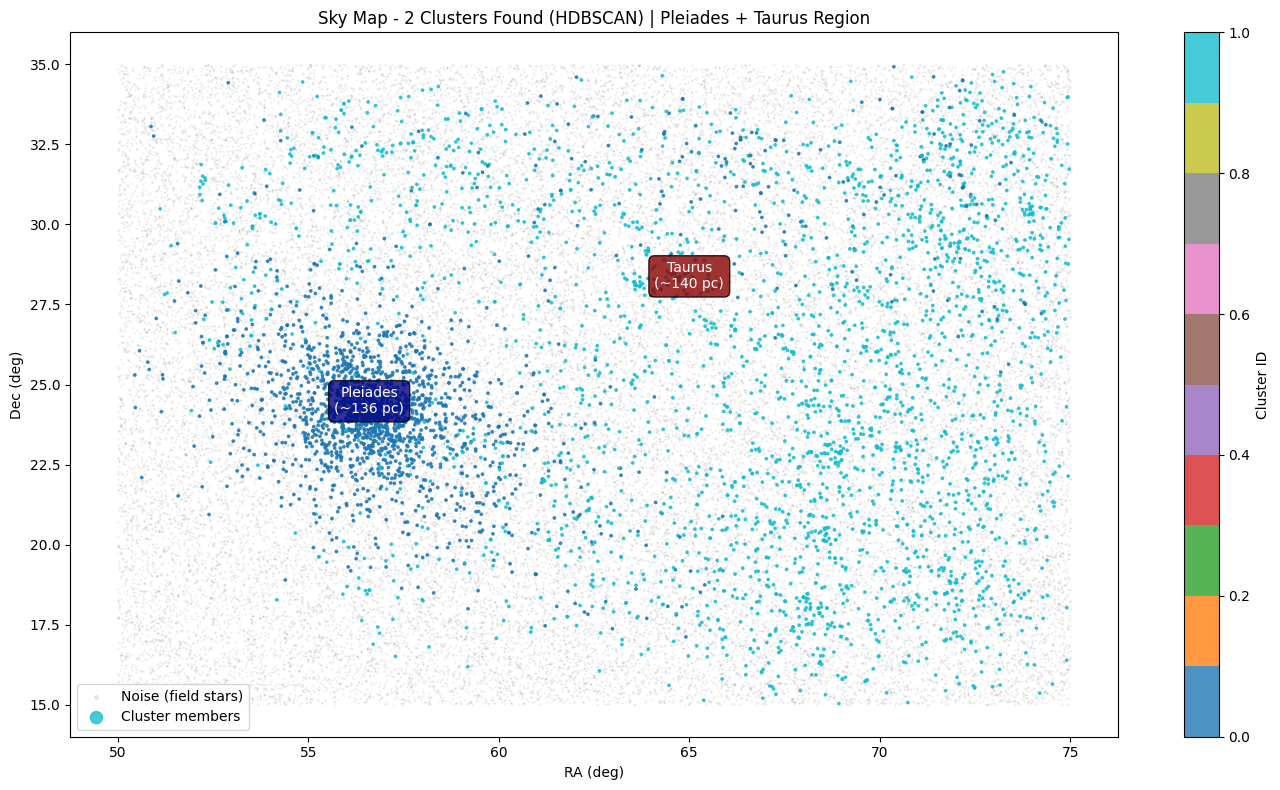

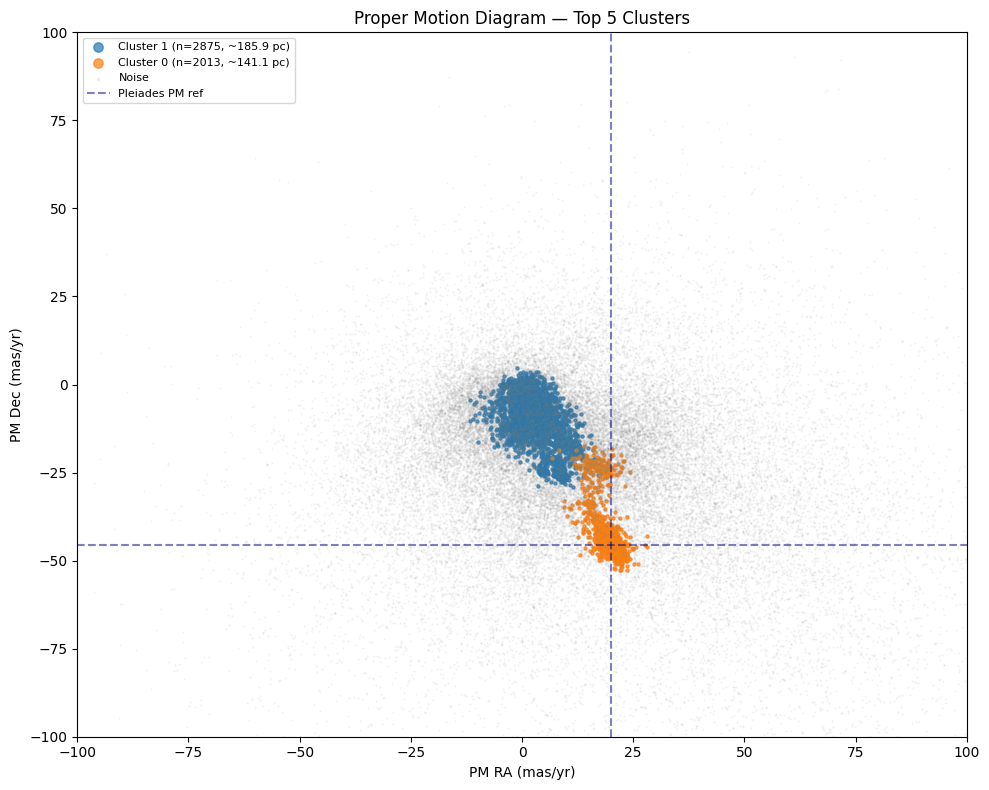


=== Pipeline Complete ===
Stars processed  : 47242
Clusters found   : 2
Noise            : 42354 (89.7%)


In [18]:
# --- Sky map dengan label Pleiades & Taurus ---
fig, ax = plt.subplots(figsize=(14, 8))

noise_mask   = df_clean['cluster'] == -1
cluster_mask = df_clean['cluster'] != -1

ax.scatter(df_clean.loc[noise_mask, 'ra'], df_clean.loc[noise_mask, 'dec'],
           s=0.3, alpha=0.15, c='gray', label='Noise (field stars)')

sc = ax.scatter(df_clean.loc[cluster_mask, 'ra'],
                df_clean.loc[cluster_mask, 'dec'],
                s=3, alpha=0.8,
                c=df_clean.loc[cluster_mask, 'cluster'],
                cmap='tab10', label='Cluster members')

plt.colorbar(sc, ax=ax, label='Cluster ID')

# annotasi
ax.annotate('Pleiades\n(~136 pc)', xy=(56.6, 24.1), fontsize=10,
            color='white', ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='navy', alpha=0.8))
ax.annotate('Taurus\n(~140 pc)', xy=(65.0, 28.0), fontsize=10,
            color='white', ha='center',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='darkred', alpha=0.8))

ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title(f'Sky Map - {n_clusters} Clusters Found (HDBSCAN) | Pleiades + Taurus Region')
ax.legend(markerscale=5, loc='lower left')
plt.tight_layout()
plt.savefig('media/clusters_sky.png', dpi=150)
plt.show()

# --- 3D interactive ---
fig_3d = px.scatter_3d(
    df_clean.sample(min(50000, len(df_clean))),   # sample agar plotly tidak berat
    x='x', y='y', z='z',
    color=df_clean.sample(min(50000, len(df_clean)))['cluster'].astype(str),
    opacity=0.5,
    title='3D Star Distribution — Pleiades + Taurus (Parsec Space)',
    labels={'x': 'X (pc)', 'y': 'Y (pc)', 'z': 'Z (pc)', 'color': 'Cluster'},
    color_discrete_sequence=px.colors.qualitative.Alphabet
)
fig_3d.update_traces(marker=dict(size=1.5))
fig_3d.write_html('media/clusters_3d.html')
fig_3d.show()

# --- Proper Motion diagram ---
fig, ax = plt.subplots(figsize=(10, 8))

top5 = summary.head(5).index.tolist()
for cid in top5:
    m = df_clean['cluster'] == cid
    ax.scatter(df_clean.loc[m, 'pmra'], df_clean.loc[m, 'pmdec'],
               s=5, alpha=0.7,
               label=f'Cluster {cid} (n={m.sum()}, ~{summary.loc[cid,"mean_dist_pc"]} pc)')

ax.scatter(df_clean.loc[noise_mask, 'pmra'], df_clean.loc[noise_mask, 'pmdec'],
           s=0.3, alpha=0.1, c='gray', label='Noise')

# Pleiades proper motion reference: pmra ~19.99, pmdec ~-45.52 mas/yr
ax.axvline(x=19.99, color='navy', linestyle='--', alpha=0.5, label='Pleiades PM ref')
ax.axhline(y=-45.52, color='navy', linestyle='--', alpha=0.5)

ax.set_xlabel('PM RA (mas/yr)')
ax.set_ylabel('PM Dec (mas/yr)')
ax.set_title('Proper Motion Diagram — Top 5 Clusters')
ax.legend(markerscale=3, fontsize=8)
ax.set_xlim(-100, 100)
ax.set_ylim(-100, 100)
plt.tight_layout()
plt.savefig('media/clusters_pm.png', dpi=150)
plt.show()

print("\n=== Pipeline Complete ===")
print(f"Stars processed  : {len(df_clean)}")
print(f"Clusters found   : {n_clusters}")
print(f"Noise            : {n_noise} ({noise_pct:.1f}%)")